# Exercise 1 (Easy)

## Question

Measure a Hadamard-superposition qubit with 100, 1000, and 10000 shots and tabulate how the measured probability converges to 0.5.

## Theory

A Hadamard gate creates an equal superposition of |0⟩ and |1⟩. Therefore, the theoretical probability of measuring either state is 0.5.

When the circuit is measured repeatedly, the observed probability may differ slightly from 0.5 because of statistical fluctuations. As the number of shots increases, the measured probability should converge closer to 0.5.

Measurement Results:


,Shots,Count of 0,Count of 1,P(0),P(1)
0,100,49,51,0.4900,0.5100
1,1000,503,497,0.5030,0.4970
2,10000,5008,4992,0.5008,0.4992


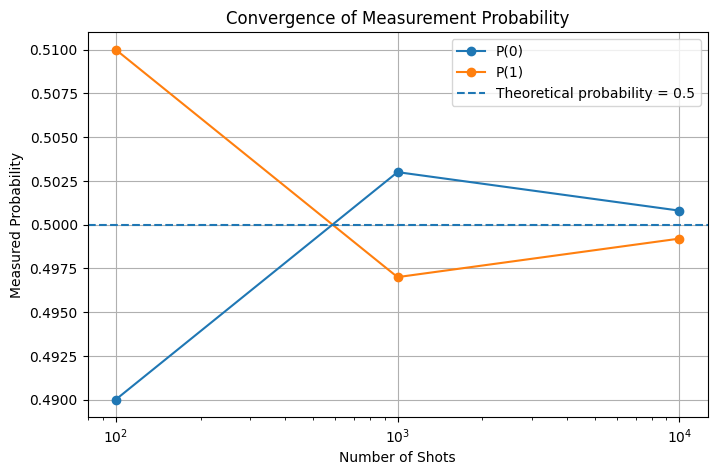

Quantum Circuit:


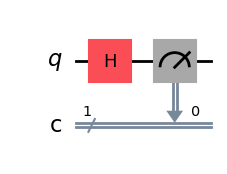

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

shots_list = [100, 1000, 10000]
results = []

simulator = AerSimulator()

for shots in shots_list:
    qc = QuantumCircuit(1, 1)

    # Create Hadamard superposition
    qc.h(0)

    # Measure the qubit
    qc.measure(0, 0)

    # Run simulation
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=shots).result()
    counts = result.get_counts()

    probability_0 = counts.get('0', 0) / shots
    probability_1 = counts.get('1', 0) / shots

    results.append({
        "Shots": shots,
        "Count of 0": counts.get('0', 0),
        "Count of 1": counts.get('1', 0),
        "P(0)": probability_0,
        "P(1)": probability_1
    })

# Create results table
df = pd.DataFrame(results)

print("Measurement Results:")
display(df)

# Plot convergence toward 0.5
plt.figure(figsize=(8, 5))
plt.plot(df["Shots"], df["P(0)"], marker='o', label="P(0)")
plt.plot(df["Shots"], df["P(1)"], marker='o', label="P(1)")
plt.axhline(0.5, linestyle='--', label="Theoretical probability = 0.5")

plt.xscale("log")
plt.xlabel("Number of Shots")
plt.ylabel("Measured Probability")
plt.title("Convergence of Measurement Probability")
plt.legend()
plt.grid(True)
plt.show()

# Display the circuit
print("Quantum Circuit:")
display(qc.draw("mpl"))

## Observation

The measured probabilities of obtaining 0 and 1 are close to 0.5. Small differences occur because of statistical fluctuations in the measurement process.

As the number of shots increases from 100 to 1000 and then to 10000, the measured probabilities generally become closer to the theoretical probability of 0.5.

## Conclusion

The Hadamard-superposition qubit was successfully measured using 100, 1000, and 10000 shots. The results demonstrate that increasing the number of measurements improves the estimate of the underlying probability distribution and causes the measured probabilities to converge toward 0.5.

# Exercise 2 (Medium)

## Question

Measure a qubit in the X-basis by applying a Hadamard gate before measurement after preparing the |+⟩ and |−⟩ states, and interpret the results.

## Theory

The X-basis consists of the states |+⟩ and |−⟩.

The states are defined as:

|+⟩ = (|0⟩ + |1⟩) / √2

|−⟩ = (|0⟩ − |1⟩) / √2

To measure in the X-basis using a computational-basis measurement, a Hadamard gate is applied before measurement.

The Hadamard gate transforms:

H|+⟩ = |0⟩

H|−⟩ = |1⟩

Therefore, measuring |+⟩ in the X-basis should give 0, while measuring |−⟩ should give 1.

|+> State Measurement Results:
{'0': 1024}

|-> State Measurement Results:
{'1': 1024}

Expected:
|+> -> 0
|-> -> 1

Circuit for |+> measurement in X-basis:


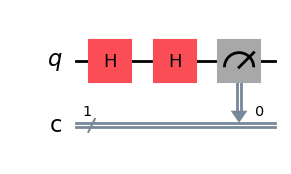


Circuit for |-> measurement in X-basis:


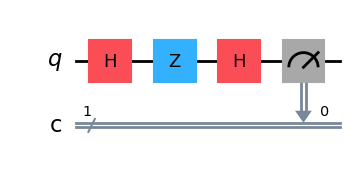

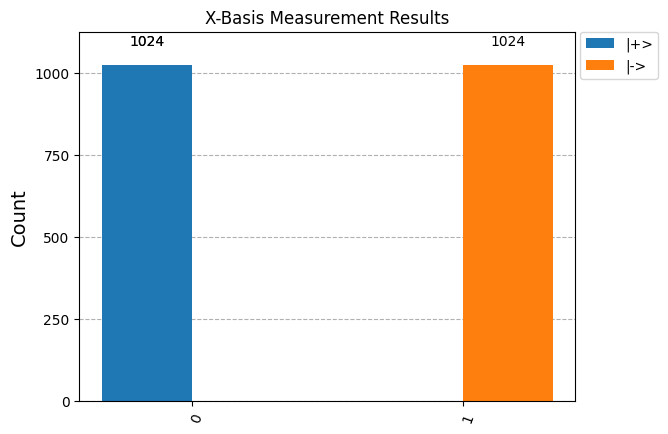

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

simulator = AerSimulator()
shots = 1024

# -----------------------------
# Prepare |+> state
# -----------------------------
plus = QuantumCircuit(1, 1)

# |0> -> |+>
plus.h(0)

# X-basis measurement: apply H
plus.h(0)

plus.measure(0, 0)

compiled_plus = transpile(plus, simulator)
result_plus = simulator.run(
    compiled_plus,
    shots=shots
).result()

counts_plus = result_plus.get_counts()

# -----------------------------
# Prepare |-> state
# -----------------------------
minus = QuantumCircuit(1, 1)

# |0> -> |+>
minus.h(0)

# |+> -> |->
minus.z(0)

# X-basis measurement: apply H
minus.h(0)

minus.measure(0, 0)

compiled_minus = transpile(minus, simulator)
result_minus = simulator.run(
    compiled_minus,
    shots=shots
).result()

counts_minus = result_minus.get_counts()

# -----------------------------
# Display results
# -----------------------------
print("|+> State Measurement Results:")
print(counts_plus)

print("\n|-> State Measurement Results:")
print(counts_minus)

print("\nExpected:")
print("|+> -> 0")
print("|-> -> 1")

# Display circuits
print("\nCircuit for |+> measurement in X-basis:")
display(plus.draw("mpl"))

print("\nCircuit for |-> measurement in X-basis:")
display(minus.draw("mpl"))

# Display histograms
display(plot_histogram(
    [counts_plus, counts_minus],
    legend=["|+>", "|->"],
    title="X-Basis Measurement Results"
))

## Observation

When the |+> state is measured in the X-basis, the result is 0 for essentially all shots.

When the |-> state is measured in the X-basis, the result is 1 for essentially all shots.

This occurs because the Hadamard gate transforms the X-basis states into the computational basis:

H|+> = |0>

H|-> = |1>

Therefore, the measurement clearly distinguishes the |+> and |-> states.

## Conclusion

The |+> and |-> states were successfully measured in the X-basis by applying a Hadamard gate before computational-basis measurement. The results demonstrate that |+> corresponds to the 0 outcome and |-> corresponds to the 1 outcome in the X-basis.

# Exercise 3 (Hard)

## Question

Perform partial measurement on one qubit of a 2-qubit Bell pair and analyse the resulting state of the unmeasured qubit.

## Theory

A Bell pair is an entangled two-qubit state:

|Φ+> = (|00> + |11>) / √2

Before measurement, neither individual qubit has a definite value.

When one qubit is measured, the entangled state collapses. If the measured qubit gives 0, the unmeasured qubit becomes |0>. If the measured qubit gives 1, the unmeasured qubit becomes |1>.

Thus, measuring one qubit determines the corresponding state of the other qubit.

Bell Pair State Before Measurement:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Bell Pair Circuit:


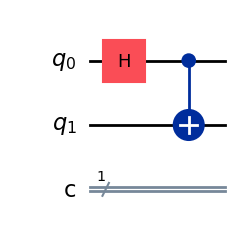


Measurement of Qubit 0:
{'0': 518, '1': 506}

Interpretation:
If Qubit 0 = 0, Qubit 1 collapses to |0>.
If Qubit 0 = 1, Qubit 1 collapses to |1>.


In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from IPython.display import display

# Create a 2-qubit Bell pair
qc = QuantumCircuit(2, 1)

# Create |Φ+> = (|00> + |11>) / √2
qc.h(0)
qc.cx(0, 1)

print("Bell Pair State Before Measurement:")
state = Statevector.from_instruction(qc)
print(state)

print("\nBell Pair Circuit:")
display(qc.draw("mpl"))

# Measure only qubit 0
qc.measure(0, 0)

# Simulate
simulator = AerSimulator()
compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

print("\nMeasurement of Qubit 0:")
print(counts)

print("\nInterpretation:")
print("If Qubit 0 = 0, Qubit 1 collapses to |0>.")
print("If Qubit 0 = 1, Qubit 1 collapses to |1>.")

## Observation

Before measurement, the two qubits are in the entangled Bell state:

|Φ+> = (|00> + |11>) / √2

Only the first qubit is measured. The measurement produces approximately equal numbers of 0 and 1 outcomes.

If the measured qubit is 0, the unmeasured qubit is correlated with it and is in state |0>.

If the measured qubit is 1, the unmeasured qubit is correlated with it and is in state |1>.

Therefore, measurement of one qubit causes the entangled state to collapse into a corresponding state of the remaining qubit.

## Conclusion

A 2-qubit Bell pair was successfully created and a partial measurement was performed on one qubit. The results demonstrate quantum state collapse and show that the unmeasured qubit is correlated with the measurement outcome of the measured qubit.

# Exercise 4 (Real-World Application)

## Question

Use repeated measurement statistics to estimate an unknown rotation angle applied to a qubit using simple quantum state tomography.

## Theory

A rotation gate changes the state of a qubit by a specified angle.

For an Ry rotation applied to |0>, the probability of measuring |1> is related to the rotation angle:

P(1) = sin²(θ/2)

Therefore, if the measurement probability P(1) is known, the rotation angle can be estimated using:

θ = 2 sin⁻¹(√P(1))

By repeatedly measuring the qubit, we can estimate P(1) and use it to recover the unknown rotation angle.

Measurement Results:
{'0': 6878, '1': 3122}

Measured Probabilities:
P(0) = 0.6878
P(1) = 0.3122

True Rotation Angle:
1.2 radians

Estimated Rotation Angle:
1.1857522356353514 radians

Estimation Error:
0.014247764364648585 radians


,Quantity,Value
0,True Angle,1.200000
1,Measured P(0),0.687800
2,Measured P(1),0.312200
3,Estimated Angle,1.185752
4,Absolute Error,0.014248



Quantum Circuit:


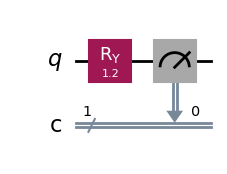

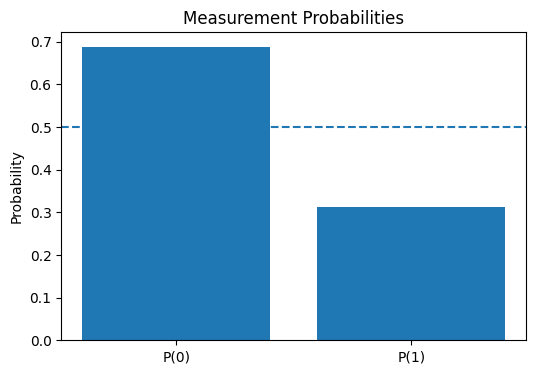

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display
import math
import pandas as pd
import matplotlib.pyplot as plt

# Unknown rotation angle used to generate the measurement data
true_angle = 1.2

# Number of repeated measurements
shots = 10000

# Create circuit
qc = QuantumCircuit(1, 1)

# Apply unknown Ry rotation
qc.ry(true_angle, 0)

# Measure the qubit
qc.measure(0, 0)

# Simulate
simulator = AerSimulator()
compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=shots
).result()

counts = result.get_counts()

# Calculate measured probability of |1>
p1 = counts.get('1', 0) / shots
p0 = counts.get('0', 0) / shots

# Estimate rotation angle
estimated_angle = 2 * math.asin(math.sqrt(p1))

print("Measurement Results:")
print(counts)

print("\nMeasured Probabilities:")
print("P(0) =", p0)
print("P(1) =", p1)

print("\nTrue Rotation Angle:")
print(true_angle, "radians")

print("\nEstimated Rotation Angle:")
print(estimated_angle, "radians")

print("\nEstimation Error:")
print(abs(true_angle - estimated_angle), "radians")

# Results table
df = pd.DataFrame({
    "Quantity": [
        "True Angle",
        "Measured P(0)",
        "Measured P(1)",
        "Estimated Angle",
        "Absolute Error"
    ],
    "Value": [
        true_angle,
        p0,
        p1,
        estimated_angle,
        abs(true_angle - estimated_angle)
    ]
})

display(df)

# Display circuit
print("\nQuantum Circuit:")
display(qc.draw("mpl"))

# Visualize measured probabilities
plt.figure(figsize=(6, 4))
plt.bar(["P(0)", "P(1)"], [p0, p1])
plt.axhline(0.5, linestyle="--")
plt.ylabel("Probability")
plt.title("Measurement Probabilities")
plt.show()

## Observation

The Ry gate applies a rotation to the initial |0> state. Repeated measurements are used to estimate the probability of obtaining |1>.

The measured probability P(1) is substituted into the relation:

θ = 2 sin⁻¹(√P(1))

The estimated rotation angle should be close to the actual rotation angle used in the experiment. Small differences occur because the measurement data is obtained from a finite number of shots.

## Conclusion

The unknown qubit rotation was estimated using repeated measurement statistics. The measured probability of obtaining |1> was used to reconstruct the rotation angle, demonstrating the basic idea of quantum state tomography.

# Exercise 5 (Challenge)

## Question

Design an experiment that distinguishes a genuinely random quantum bit generator from a biased classical pseudo-random generator using statistical hypothesis testing on measurement data.

## Theory

A quantum random bit can be generated by preparing a qubit in an equal superposition using a Hadamard gate and measuring it.

For an ideal quantum random bit generator:

P(0) = 0.5
P(1) = 0.5

A biased classical generator may produce 0 and 1 with unequal probabilities.

A statistical hypothesis test can be used to determine whether the observed measurement data is consistent with an unbiased 50-50 distribution.

Quantum Generator Results:
{'1': 5043, '0': 4957}

Classical Biased Generator Results:
{'0': 7113, '1': 2887}

Quantum Chi-Square Test:
Statistic = 0.7396
p-value = 0.3897890425036168

Classical Chi-Square Test:
Statistic = 1785.9076
p-value = 0.0

Interpretation:
Quantum data is consistent with an unbiased 50-50 distribution.
Classical data significantly differs from a 50-50 distribution.


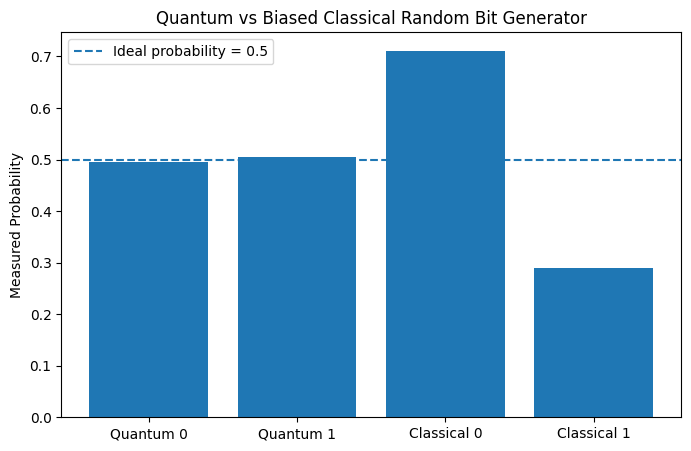


Quantum Circuit:


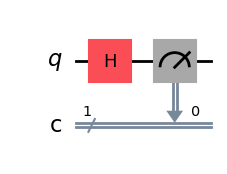

In [9]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

shots = 10000

# --------------------------------
# Quantum random bit generator
# --------------------------------
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

simulator = AerSimulator()
compiled = transpile(qc, simulator)

quantum_result = simulator.run(
    compiled,
    shots=shots
).result()

quantum_counts = quantum_result.get_counts()

q0 = quantum_counts.get("0", 0)
q1 = quantum_counts.get("1", 0)

# --------------------------------
# Biased classical generator
# --------------------------------
np.random.seed(42)

classical_bits = np.random.choice(
    [0, 1],
    size=shots,
    p=[0.70, 0.30]
)

c0 = np.sum(classical_bits == 0)
c1 = np.sum(classical_bits == 1)

# --------------------------------
# Chi-square hypothesis test
# --------------------------------
expected = [shots / 2, shots / 2]

quantum_test = chisquare([q0, q1], expected)
classical_test = chisquare([c0, c1], expected)

print("Quantum Generator Results:")
print(quantum_counts)

print("\nClassical Biased Generator Results:")
print({"0": int(c0), "1": int(c1)})

print("\nQuantum Chi-Square Test:")
print("Statistic =", quantum_test.statistic)
print("p-value =", quantum_test.pvalue)

print("\nClassical Chi-Square Test:")
print("Statistic =", classical_test.statistic)
print("p-value =", classical_test.pvalue)

# --------------------------------
# Interpretation
# --------------------------------
alpha = 0.05

print("\nInterpretation:")

if quantum_test.pvalue > alpha:
    print("Quantum data is consistent with an unbiased 50-50 distribution.")
else:
    print("Quantum data significantly differs from a 50-50 distribution.")

if classical_test.pvalue > alpha:
    print("Classical data is consistent with an unbiased 50-50 distribution.")
else:
    print("Classical data significantly differs from a 50-50 distribution.")

# --------------------------------
# Probability comparison
# --------------------------------
quantum_p0 = q0 / shots
quantum_p1 = q1 / shots

classical_p0 = c0 / shots
classical_p1 = c1 / shots

labels = ["Quantum 0", "Quantum 1", "Classical 0", "Classical 1"]
values = [quantum_p0, quantum_p1, classical_p0, classical_p1]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.axhline(0.5, linestyle="--", label="Ideal probability = 0.5")
plt.ylabel("Measured Probability")
plt.title("Quantum vs Biased Classical Random Bit Generator")
plt.legend()
plt.show()

print("\nQuantum Circuit:")
display(qc.draw("mpl"))

## Observation

The quantum generator produces approximately equal numbers of 0 and 1 because the Hadamard gate creates an equal superposition.

The classical generator was intentionally biased to produce 0 with probability 0.70 and 1 with probability 0.30. Therefore, its measurement distribution is significantly different from the expected 50-50 distribution.

The chi-square test is used to compare the observed results with the expected unbiased distribution.

## Hypothesis Testing

Null hypothesis (H₀):

The generated bits follow an unbiased 50-50 distribution.

Alternative hypothesis (H₁):

The generated bits do not follow an unbiased 50-50 distribution.

Significance level:

α = 0.05

If p-value > 0.05, we fail to reject H₀.

If p-value < 0.05, we reject H₀.

## Conclusion

The experiment demonstrates how statistical hypothesis testing can be used to distinguish an approximately unbiased quantum random bit generator from a deliberately biased classical pseudo-random generator.

The quantum generator is expected to be consistent with a 50-50 distribution, while the biased classical generator should be statistically distinguishable from the unbiased distribution.